# 03B Continuous State DP: Interpolation Methods

[![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)


In [1]:
# === Environment Setup ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize_scalar
from scipy.interpolate import interp1d
from IPython.display import display, Markdown

# --- Configuration ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.figsize': (11, 7), 'figure.dpi': 130})
%config InlineBackend.figure_format = 'retina'
np.set_printoptions(suppress=True, linewidth=120, precision=4)



Environment initialized.


# The Lens: Continuous States Without Grid Errors

**What problem are we solving?**
When state variables are continuous, coarse grids can distort optimal decisions. We need a way to evaluate value functions off-grid and allow smooth policy choices.

**Why this method?**
Interpolation combined with continuous optimization lets us solve continuous-state dynamic programs with far less discretization error. This is a standard tool for consumption–savings, growth, and asset pricing models.

### Learning Objectives
* **Solve** continuous-state DP problems with interpolation-based value function iteration.
* **Implement** continuous choice optimization using `minimize_scalar`.
* **Interpret** policy functions and steady-state behavior for continuous models.

### Prerequisites
* **`03-Economic-Modeling/03A_Discrete_Choice_DP_Rust.ipynb`**: Discrete-choice DP structure.
* **`02-Numerical-Methods/06_Interpolation_and_Approximation.ipynb`**: Interpolation basics.
* **Python:** NumPy and SciPy optimization.


### Table of Contents
1. [The Lens: Continuous States Without Grid Errors](#The-Lens:-Continuous-States-Without-Grid-Errors)
2. [Continuous State DP: Consumption-Savings](#Continuous-State-DP:-Consumption-Savings)
3. [Solving Continuous DP with Interpolation](#Solving-Continuous-DP-with-Interpolation)
4. [Summary](#Summary)

In [4]:
class ContinuousDPSolver:
    """
    Solves a consumption-savings problem using VFI with Linear Interpolation.
    """
    def __init__(self, alpha=0.33, beta=0.96, delta=0.05, A=1.0, n_grid=50):
        self.alpha, self.beta, self.delta, self.A = alpha, beta, delta, A
        
        # Steady state capital (for grid centering)
        # 1 = beta * (alpha A k^(alpha-1) + 1 - delta)
        r_target = 1/beta - (1-delta)
        self.k_ss = (alpha * A / r_target)**(1/(1-alpha))
        
        # Create grid around steady state
        self.k_grid = np.linspace(0.5*self.k_ss, 1.5*self.k_ss, n_grid)
        self.V = np.zeros(n_grid) # Initial guess
        
    def utility(self, c):
        if c <= 0: return -1e10
        return np.log(c)
    
    def rhs(self, k, k_prime, V_interp):
        """Right Hand Side of Bellman: u(c) + beta * V(k')"""
        # Resource constraint: c = f(k) + (1-delta)k - k'
        production = self.A * k**self.alpha + (1-self.delta)*k
        c = production - k_prime
        
        if c <= 0:
            return -1e10
        
        # Value of next state (interpolated)
        # We handle extrapolation by clamping (safe for this convex problem)
        if k_prime < self.k_grid[0] or k_prime > self.k_grid[-1]:
            return -1e10 # Penalize going off grid
            
        v_next = V_interp(k_prime)
        return self.utility(c) + self.beta * v_next

    def solve(self, tol=1e-5, max_iter=200):
        V_old = np.copy(self.V)
        policy_k = np.zeros_like(self.k_grid)
        
        for i in range(max_iter):
            # Create interpolation function for current V
            V_interp = interp1d(self.k_grid, V_old, kind='linear', fill_value="extrapolate")
            V_new = np.zeros_like(V_old)
            
            for j, k in enumerate(self.k_grid):
                # Maximize RHS with respect to k_prime
                # Since optimizers minimize, we minimize -RHS
                production = self.A * k**self.alpha + (1-self.delta)*k
                bounds = (self.k_grid[0], min(production, self.k_grid[-1]))
                
                res = minimize_scalar(
                    lambda kp: -self.rhs(k, kp, V_interp),
                    bounds=bounds,
                    method='bounded'
                )
                
                V_new[j] = -res.fun
                policy_k[j] = res.x
            
            diff = np.max(np.abs(V_new - V_old))
            if diff < tol:
                print(f"Continuous VFI Converged in {i} iterations.")
                self.V = V_new
                self.policy = policy_k
                return
            
            V_old = V_new
            
        self.V = V_old
        self.policy = policy_k

cont_model = ContinuousDPSolver()
cont_model.solve()

<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_32222/1435150602.py:3: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(cont_model.k_grid, cont_model.policy, label='Optimal Policy $k^\prime(k)$', linewidth=2)
/tmp/ipykernel_32222/1435150602.py:9: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('Next Period Capital $k^\prime$')


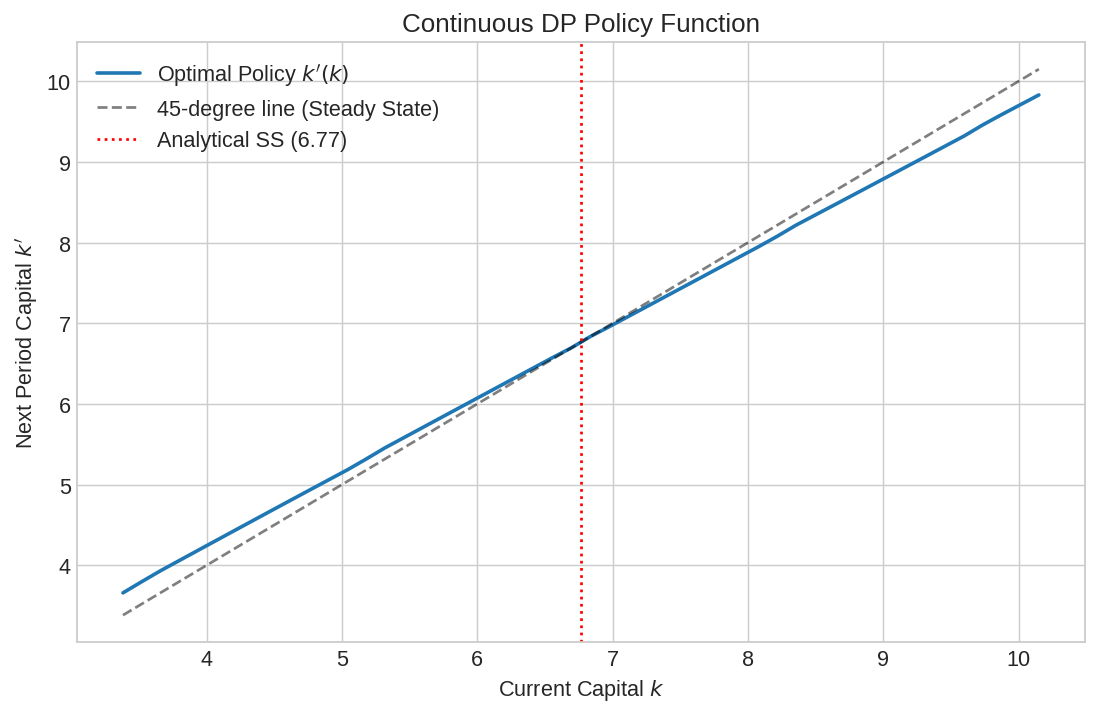

In [5]:
# Compare Policy Function with 45-degree line
plt.figure(figsize=(10, 6))
plt.plot(cont_model.k_grid, cont_model.policy, label='Optimal Policy $k^\prime(k)$', linewidth=2)
plt.plot(cont_model.k_grid, cont_model.k_grid, 'k--', label='45-degree line (Steady State)', alpha=0.5)
plt.axvline(cont_model.k_ss, color='red', linestyle=':', label=f'Analytical SS ({cont_model.k_ss:.2f})')

plt.title('Continuous DP Policy Function')
plt.xlabel('Current Capital $k$')
plt.ylabel('Next Period Capital $k^\prime$')
plt.legend()
plt.show()

# Summary

We have explored two advanced DP techniques:

1.  **Discrete Choice (Rust):** Solved by defining conditional value functions for each discrete alternative and taking the upper envelope. This handles the non-differentiability inherent in discrete choices.
2.  **Continuous States (Interpolation):** Solved by approximating the value function between grid points. This allows the agent to choose *any* real number for capital, eliminating the quantization error of grid-based methods and providing accurate steady-state values.